# Holstein JLD2 Dataset Inspection
`george_325.jld2` — DQMC data for the Holstein model

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

JLD2 = 'Data/datasets/george_325.jld2'

with h5py.File(JLD2, 'r') as f:
    G_r = f['G_r'][()]   # (100, 201, 16, 4, 20) — bins × ntau × betas × Omegas × ns
    dos = f['dos'][()]   # (601, 16, 4, 20)       — ws × betas × Omegas × ns
    ws  = f['ws'][()]

ns     = np.arange(0.05, 1.01, 0.05)   # 20 values
omegas = np.arange(0.5,  2.01, 0.5)    #  4 values
betas  = np.arange(5.0,  21.0, 1.0)    # 16 values

print(f'G_r  shape: {G_r.shape}  (bins × ntau × betas × Omegas × ns)')
print(f'dos  shape: {dos.shape}  (ws × betas × Omegas × ns)')
print(f'ws   shape: {ws.shape}')

G_r  shape: (100, 201, 16, 4, 20)  (bins × ntau × betas × Omegas × ns)
dos  shape: (601, 16, 4, 20)  (ws × betas × Omegas × ns)
ws   shape: (601,)


## Zero check

In [2]:
print('=== G_r ===')
print(f'  nonzero elements : {np.count_nonzero(G_r):,} / {G_r.size:,}')
print(f'  nonzero bytes    : {np.count_nonzero(G_r.view(np.uint8)):,} / {G_r.nbytes:,}')
print(f'  min / max        : {G_r.min():.4g} / {G_r.max():.4g}')
print()
print('=== dos ===')
print(f'  nonzero elements : {np.count_nonzero(dos):,} / {dos.size:,}')
print(f'  min / max        : {dos.min():.4g} / {dos.max():.4g}')
print()
print('=== ws ===')
print(f'  range  : {ws[0]:.2f} to {ws[-1]:.2f},  {len(ws)} points')

=== G_r ===
  nonzero elements : 0 / 25,728,000
  nonzero bytes    : 0 / 205,824,000
  min / max        : 0 / 0

=== dos ===
  nonzero elements : 769,280 / 769,280
  min / max        : 1.738e-08 / 0.4214

=== ws ===
  range  : -15.00 to 15.00,  601 points


## G_r slice heatmap — visually confirm zeros

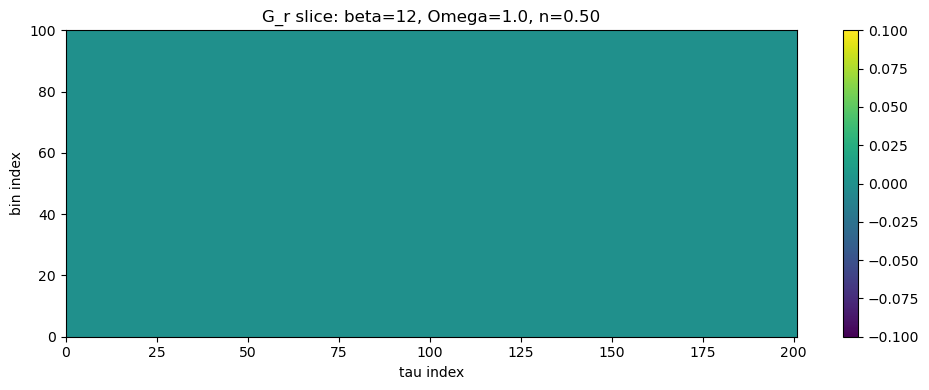

Slice min/max: 0 / 0


In [3]:
# Show a 2D slice: bins vs taus for the middle simulation point
bi, oi, ni = 7, 1, 9   # beta=12, Omega=1.0, n=0.5
slice_2d = G_r[:, :, bi, oi, ni]   # (100, 201)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(slice_2d, aspect='auto', origin='lower',
               extent=[0, 201, 0, 100])
plt.colorbar(im, ax=ax)
ax.set_xlabel('tau index')
ax.set_ylabel('bin index')
ax.set_title(f'G_r slice: beta={betas[bi]:.0f}, Omega={omegas[oi]:.1f}, n={ns[ni]:.2f}')
plt.tight_layout()
plt.show()
print(f'Slice min/max: {slice_2d.min():.4g} / {slice_2d.max():.4g}')

## DOS — sample spectral functions

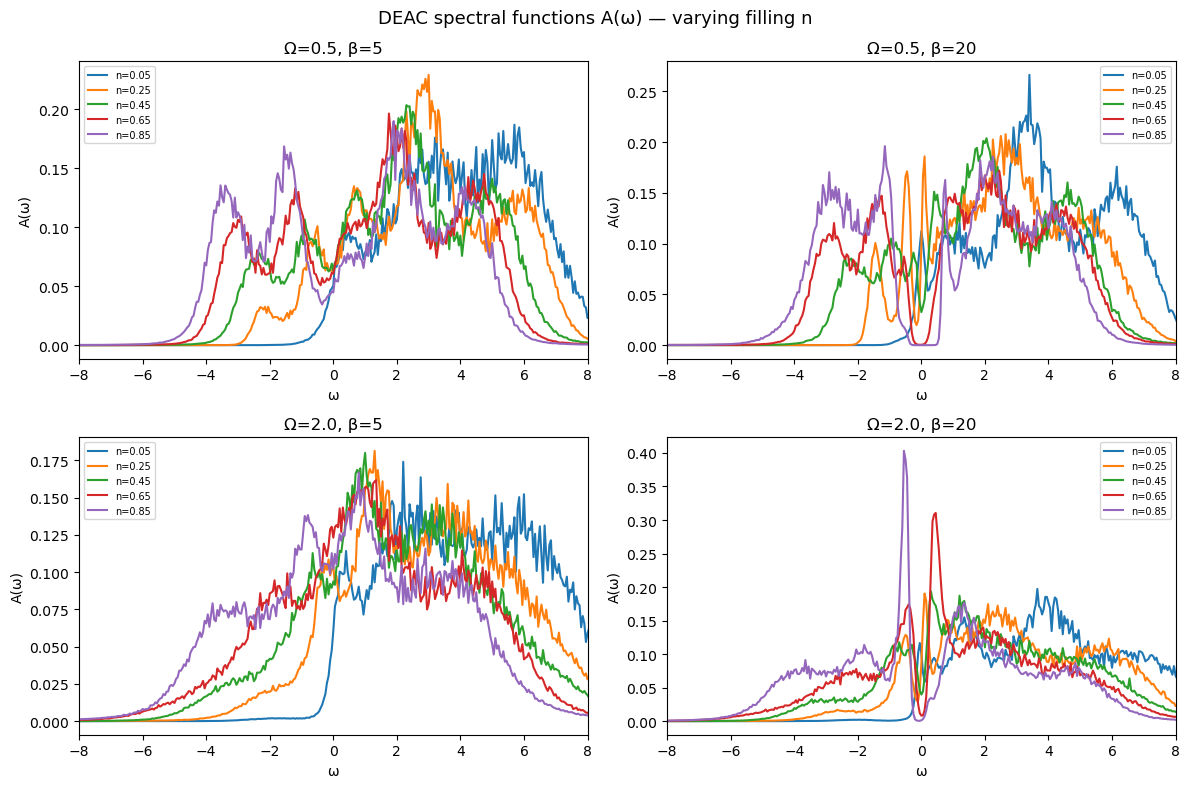

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
axes = axes.flatten()

for ax_i, (oi, label) in enumerate(zip([0,0,3,3], ['Ω=0.5','Ω=0.5','Ω=2.0','Ω=2.0'])):
    bi = [0, 15][ax_i % 2]   # beta=5 or beta=20
    ax = axes[ax_i]
    for ni in range(0, 20, 4):  # every 4th filling
        ax.plot(ws, dos[:, bi, oi, ni], label=f'n={ns[ni]:.2f}')
    ax.set_title(f'{label}, β={betas[bi]:.0f}')
    ax.set_xlabel('ω')
    ax.set_ylabel('A(ω)')
    ax.legend(fontsize=7)
    ax.set_xlim(-8, 8)

plt.suptitle('DEAC spectral functions A(ω) — varying filling n', fontsize=13)
plt.tight_layout()
plt.show()

## DOS normalization check

Normalization  min=0.999903  max=1.000000  mean=0.999994


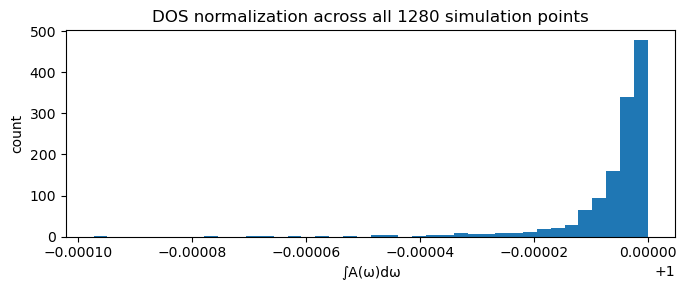

In [7]:
# Integral of A(omega) should be 1 for all parameter combos
norms = np.trapezoid(dos, ws, axis=0)   # (16, 4, 20)
print(f'Normalization  min={norms.min():.6f}  max={norms.max():.6f}  mean={norms.mean():.6f}')

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(norms.flatten(), bins=40)
ax.set_xlabel('∫A(ω)dω')
ax.set_ylabel('count')
ax.set_title('DOS normalization across all 1280 simulation points')
plt.tight_layout()
plt.show()

## Phase diagram view — peak position of A(ω)

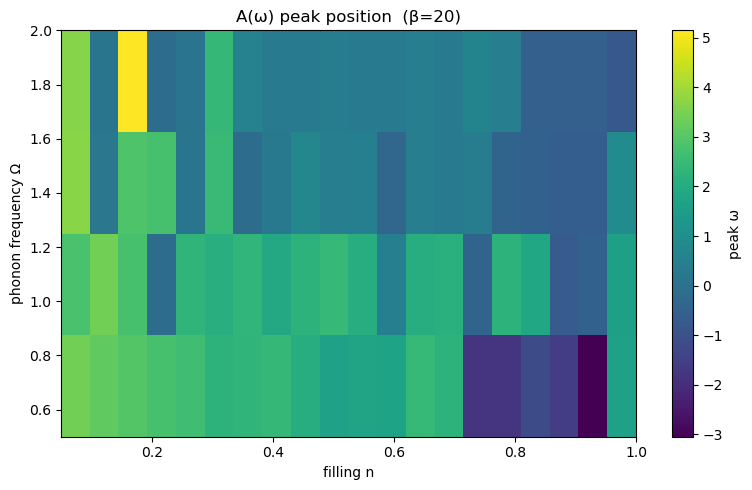

In [8]:
# Peak frequency as a function of (n, Omega) at fixed beta=20
bi = 15   # beta=20
peak_w = ws[np.argmax(dos[:, bi, :, :], axis=0)]   # (4, 20)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(peak_w, aspect='auto', origin='lower',
               extent=[ns[0], ns[-1], omegas[0], omegas[-1]])
plt.colorbar(im, ax=ax, label='peak ω')
ax.set_xlabel('filling n')
ax.set_ylabel('phonon frequency Ω')
ax.set_title(f'A(ω) peak position  (β={betas[bi]:.0f})')
plt.tight_layout()
plt.show()